# WildChat EDA

Exploratory data analysis of the [WildChat](https://huggingface.co/datasets/allenai/WildChat) conversation dataset.  
Mid-stage tables are saved under `eda_output/` (not under `data/`). Set `LOAD_FROM_SAVED = True` to load from disk instead of recomputing.

In [1]:
# Configuration (edit and run first)
SAMPLE_N = 5000          # exact number of conversations; set to None to use SAMPLE_PCT
SAMPLE_PCT = None        # e.g. 0.01 for 1%; used only when SAMPLE_N is None
LOAD_FROM_SAVED = False  # if True, load step tables from eda_output/ instead of recomputing
EDA_OUTPUT_DIR = "eda_output"  # do not use data/ for these outputs
RANDOM_SEED = 42

In [2]:
from pathlib import Path
import pandas as pd
from datasets import load_dataset

from eda_utils import (
    sample_by_conversation,
    build_step3_basic_counts,
    build_step4_message_length,
    build_step5_temporal,
    build_step6_moderation,
    build_step7_empty_inputs,
    build_step8_keyword_counts,
    build_step9_summary,
    load_or_build,
    ensure_output_dir,
)

/Users/Larry.Jin/miniconda3/envs/wildchat/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load full train split, then sample by conversation (whole conversations only)
dataset = load_dataset("allenai/WildChat", split="train")
sampled = sample_by_conversation(dataset, n=SAMPLE_N, pct=SAMPLE_PCT, seed=RANDOM_SEED)
df = sampled.to_pandas()
print(f"Sampled {len(df)} conversations (full dataset has {len(dataset)}).")
df.head(2)

Sampled 5000 conversations (full dataset has 529428).


,conversation_id,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted
0,6c10559df69e1f823600f79204c9925e,gpt-3.5-turbo,2023-05-20 07:52:37+00:00,[{'content': 'how to get docker container file...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0001777968427632004, 'i...",False,False
1,edaa2bb0c3a3858eaa69aafada51f4ae,gpt-3.5-turbo,2023-04-21 16:25:56+00:00,"[{'content': 'One chicken plus 2 chickens, how...",2,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00011031814210582525, '...",False,False


## Schema and sample

Each row is one conversation. The `conversation` column is a list of messages (order = sequence).  
Columns: `conversation_id`, `model`, `timestamp`, `conversation`, `turn`, `language`, `openai_moderation`, `detoxify_moderation`, `toxic`, `redacted`.

In [6]:
print("Columns:", sampled.column_names)
print("\nFeatures:", sampled.features)
# Flatten one short conversation for clarity
row = df.iloc[0]
conv = row["conversation"]
if conv is not None and len(conv) > 0:
    flat = [{"idx": i, "role": m.get("role"), "content_len": len((m.get("content") or "")), "language": m.get("language")} for i, m in enumerate(conv)]
    pd.DataFrame(flat)

Columns: ['conversation_id', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted']

Features: {'conversation_id': Value('string'), 'model': Value('string'), 'timestamp': Value('timestamp[s, tz=UTC]'), 'conversation': List({'content': Value('string'), 'language': Value('string'), 'redacted': Value('bool'), 'role': Value('string'), 'toxic': Value('bool')}), 'turn': Value('int64'), 'language': Value('string'), 'openai_moderation': List({'categories': {'harassment': Value('bool'), 'harassment/threatening': Value('bool'), 'hate': Value('bool'), 'hate/threatening': Value('bool'), 'self-harm': Value('bool'), 'self-harm/instructions': Value('bool'), 'self-harm/intent': Value('bool'), 'sexual': Value('bool'), 'sexual/minors': Value('bool'), 'violence': Value('bool'), 'violence/graphic': Value('bool')}, 'category_scores': {'harassment': Value('float64'), 'harassment/threatening': Value('float64'), 'hate': Value('float64'), 'hat

In [7]:
import textwrap

# Sample one conversation and print full messages (pretty format)
row = df.iloc[3]
conv = row["conversation"]
width = 80
if conv is not None and len(conv) > 0:
    print(f"Conversation (id={row.get('conversation_id', 'N/A')}, turn={row.get('turn', 'N/A')})\n")
    for i, m in enumerate(conv):
        role = m.get("role", "?")
        content = (m.get("content") or "").strip()
        print(f"--- Message {i + 1} [{role}] ---")
        print(textwrap.fill(content, width=width))
        print()

Conversation (id=87d49aeba9c3198305b3880c2bd275cd, turn=2)

--- Message 1 [user] ---
hi

--- Message 2 [assistant] ---
Hello! How can I assist you today?

--- Message 3 [user] ---
what's 1-1

--- Message 4 [assistant] ---
The result of 1 minus 1 is 0.



## Step 3: Basic counts and distributions

Model, turn distribution, top languages.

In [8]:
path_step3 = Path(EDA_OUTPUT_DIR) / "step3_basic_counts.parquet"
step3_df = load_or_build(path_step3, LOAD_FROM_SAVED, build_step3_basic_counts, df)
# Display: model, turn, language
model_rows = step3_df[step3_df["metric"].str.startswith("model_")]
turn_rows = step3_df[step3_df["metric"].str.startswith("turn_") | step3_df["metric"].str.contains("single_turn|multi_turn", regex=True)]
lang_rows = step3_df[step3_df["metric"].str.startswith("language_")]
print("Model counts:"); display(model_rows)
print("Turn stats:"); display(turn_rows)
print("Top languages:"); display(lang_rows.head(15))

Model counts:


,metric,value
1,model_gpt-3.5-turbo,4472.0
2,model_gpt-4,524.0
3,model_gpt-4-1106-preview,4.0


Turn stats:


,metric,value
4,turn_min,1.00
5,turn_max,76.00
6,turn_mean,2.38
7,turn_median,1.00
8,single_turn_count,2897.00
9,multi_turn_count,2103.00


Top languages:


,metric,value
10,language_English,2691.0
11,language_Chinese,991.0
12,language_Russian,453.0
13,language_French,150.0
14,language_German,129.0
15,language_Spanish,108.0
16,language_Arabic,70.0
17,language_Portuguese,65.0
18,language_Vietnamese,39.0
19,language_Italian,30.0


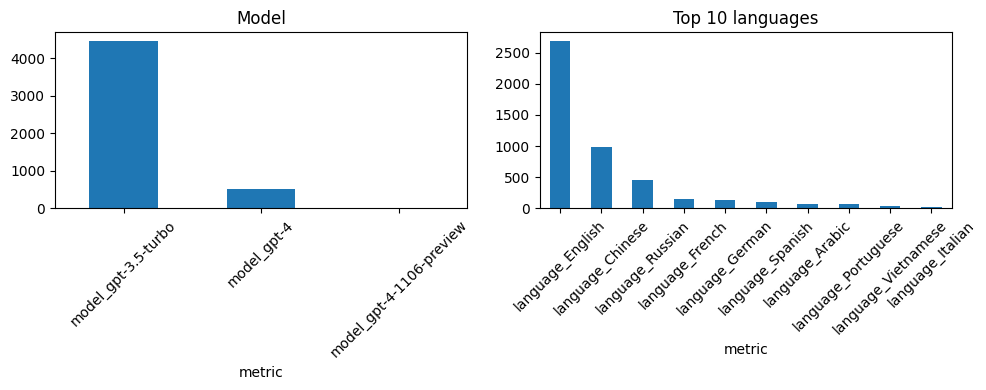

In [9]:
# Plots: model and top 10 languages
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
model_rows.set_index("metric")["value"].plot(kind="bar", ax=ax1, title="Model")
ax1.tick_params(axis="x", rotation=45)
lang_rows.head(10).set_index("metric")["value"].plot(kind="bar", ax=ax2, title="Top 10 languages")
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Step 4: Conversation and message length

Per-conversation message counts and character lengths (user vs assistant).

In [10]:
path_step4 = Path(EDA_OUTPUT_DIR) / "step4_message_length.parquet"
step4_df = load_or_build(path_step4, LOAD_FROM_SAVED, build_step4_message_length, df)
# Format floats without trailing zeros
def _fmt(x):
    if pd.isna(x): return ""
    return str(int(x)) if x == int(x) else f"{x:.2f}".rstrip("0").rstrip(".")
display(step4_df.head(10).style.format({"user_mean_words": _fmt, "assistant_mean_words": _fmt}))
print("Summary (median/mean words per message):")
display(step4_df[["user_mean_words", "assistant_mean_words"]].describe().style.format(_fmt))

,conversation_idx,n_messages,total_chars,user_mean_len,user_total_len,assistant_mean_len,assistant_total_len,n_user_msgs,n_assistant_msgs
0,0,2,1170,58,58,1112,1112,1,1
1,1,4,121,39,78,21.5,43,2,2
2,2,4,2337,242,484,926.5,1853,2,2
3,3,4,75,6,12,31.5,63,2,2
4,4,2,378,21,21,357,357,1,1
5,5,8,4457,190.5,762,923.75,3695,4,4
6,6,2,2413,137,137,2276,2276,1,1
7,7,2,1768,342,342,1426,1426,1,1
8,8,4,6804,92,184,3310,6620,2,2
9,9,42,16734,37.43,786,759.43,15948,21,21


Summary (median/mean message length):


,user_mean_len,assistant_mean_len
count,5000,5000
mean,1005.95,1387.06
std,2314.12,1357.76
min,0,1
25%,46,420.16
50%,148,1036.75
75%,670.25,2015.25
max,34649,19769


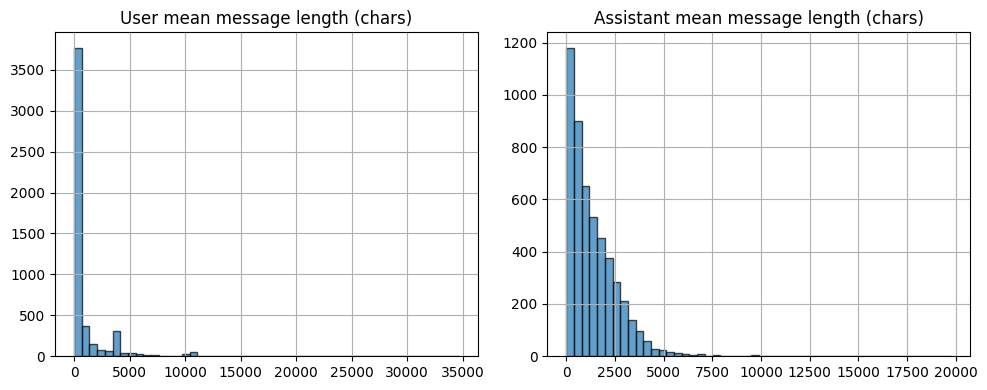

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
step4_df["user_mean_words"].hist(ax=ax1, bins=50, edgecolor="black", alpha=0.7)
ax1.set_title("User mean words per message")
step4_df["assistant_mean_words"].hist(ax=ax2, bins=50, edgecolor="black", alpha=0.7)
ax2.set_title("Assistant mean words per message")
plt.tight_layout()
plt.show()

## Step 5: Temporal distribution

Conversation count over time.

,date,count
0,2023-04-10,18
1,2023-04-11,14
2,2023-04-12,18
3,2023-04-13,21
4,2023-04-14,27
5,2023-04-15,9
6,2023-04-16,21
7,2023-04-17,16
8,2023-04-18,17
9,2023-04-19,24


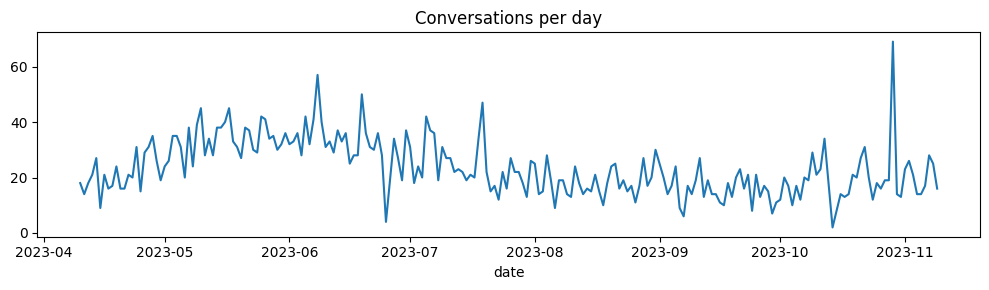

In [12]:
path_step5 = Path(EDA_OUTPUT_DIR) / "step5_temporal.parquet"
step5_df = load_or_build(path_step5, LOAD_FROM_SAVED, build_step5_temporal, df)
display(step5_df.head(10))
step5_df.set_index("date")["count"].plot(figsize=(10, 3), title="Conversations per day")
plt.tight_layout()
plt.show()

## Step 6: Moderation and quality flags

Toxic / redacted counts; post-filter dataset should be mostly non-toxic.

In [13]:
path_step6 = Path(EDA_OUTPUT_DIR) / "step6_moderation.parquet"
step6_df = load_or_build(path_step6, LOAD_FROM_SAVED, build_step6_moderation, df)
display(step6_df)

,metric,value
0,toxic_true,0.0
1,toxic_false,5000.0
2,redacted_true,31.0
3,redacted_false,4969.0
4,detoxify_toxicity_max_mean,0.0


## Step 7: Empty and short user inputs

Conversations with at least one empty or whitespace-only user message.

In [14]:
path_step7 = Path(EDA_OUTPUT_DIR) / "step7_empty_inputs.parquet"
step7_df = load_or_build(path_step7, LOAD_FROM_SAVED, build_step7_empty_inputs, df)
display(step7_df.head(10))

,metric,value
0,conversations_with_empty_user_input,0.0
1,pct_with_empty_user_input,0.0


## Step 8: Content sampling and keyword counts

Sample conversations by turn count; optional keyword counts.

In [15]:
path_step8 = Path(EDA_OUTPUT_DIR) / "step8_keyword_counts.parquet"
step8_df = load_or_build(path_step8, LOAD_FROM_SAVED, build_step8_keyword_counts, df)
display(step8_df)

,keyword,conversation_count
0,code,0
1,translate,0
2,write,0
3,python,0
4,explain,0


In [16]:
# Sample conversations: one single-turn, one 3-turn, one long
def show_convo(conv, max_len=200):
    if conv is None or len(conv) == 0:
        print("  (none)")
        return
    for i, m in enumerate(conv):
        c = (m.get("content") or "")[:max_len]
        if len((m.get("content") or "")) > max_len:
            c += "..."
        print(f"  [{i}] {m.get('role')}: {c}")
single = df[df["turn"] == 1].iloc[0]["conversation"]
three = df[df["turn"] == 3]
three = three.iloc[len(three) // 2]["conversation"] if len(three) else []
long_df = df[df["turn"] >= 10]
long_conv = long_df.iloc[0]["conversation"] if len(long_df) else []
print("Single-turn:"); show_convo(single)
print("\n3-turn (middle):"); show_convo(three)
print("\nLong (>=10 turns):"); show_convo(long_conv)

Single-turn:
  [0] user: how to get docker container file from docker compose build
  [1] assistant: The Docker Compose command `docker-compose build` builds an image for each service defined in the `docker-compose.yml` file. To get the container file for a particular service, follow these steps:

1....

3-turn (middle):
  [0] user: Hi there
  [1] assistant: Hello! How can I assist you today?
  [2] user: Write me a brief article on home improvement and decluttering.
  [3] assistant: Title: Elevate Your Living Space with Home Improvement and Decluttering

Introduction:
In the chaotic world we live in, finding solace in a clutter-free and well-organized home has become increasingly...
  [4] user: Write me a brief essay about the thriving through home improvement and decluttering
  [5] assistant: Title: Thriving Through Home Improvement and Decluttering

Introduction:
In a world where we often feel overwhelmed by the demands of our busy lives, the concept of thriving seems like an elusive

## Step 9: Summary table

One-row summary: total conversations, turns, date range, top languages, model counts, % redacted, % empty user input, message lengths.

In [17]:
path_step9 = Path(EDA_OUTPUT_DIR) / "step9_summary.parquet"
step9_df = load_or_build(
    path_step9, LOAD_FROM_SAVED, build_step9_summary,
    df, step3_df, step4_df, step5_df, step6_df, step7_df,
)
display(step9_df.T)

,0
total_conversations,5000
total_turns,11900
date_min,2023-04-10 01:25:42+00:00
date_max,2023-11-09 15:22:35+00:00
top3_languages,"English(2691), Chinese(991), Russian(453)"
model_counts,"gpt-3.5-turbo(4472), gpt-4(524), gpt-4-1106-pr..."
pct_redacted,0.62
pct_empty_user_input,0.0
median_user_msg_len,148.0
mean_user_msg_len,1005.950298


## Takeaways

Use the summary and step tables above to decide filters for downstream use (e.g. instruction tuning): language, turn range, redaction, empty inputs. All mid-stage tables are under `eda_output/`; set `LOAD_FROM_SAVED = True` to skip recomputation.

## Export English-only (full dataset)

Filter to English conversations and save to chunked parquet files for easier loading. Uses the **full** dataset (not the sampled 5000). Run this once to create `data/english_chunks/`; then `insights_analysis.ipynb` can load from these files instead of the Hugging Face dataset.

In [18]:
# Full dataset: load, filter to English, write chunked parquet (not the 5000 sample)
from eda_utils import export_english_chunked_parquet, ensure_output_dir

ENGLISH_CHUNKS_DIR = "data/english_chunks"
CHUNK_SIZE = 50_000  # rows per parquet file

dataset_full = load_dataset("allenai/WildChat", split="train")
out_dir, n_written = export_english_chunked_parquet(
    dataset_full,
    output_dir=ENGLISH_CHUNKS_DIR,
    chunk_size=CHUNK_SIZE,
    language_col="language",
    language_value="English",
)
print(f"Wrote {n_written} English conversations to {out_dir} in chunked parquet files.")

Wrote 284168 English conversations to data/english_chunks in chunked parquet files.



3 Potential topics to explore: 

- 1. Topic/Industry Specific Analysis - Choose one domain (e.g., health, finance, education) and analyze how users engage with it

- ​2. Intent/Semantic Analysis - What themes appear most often? Are there emerging or underserved areas of interest?

- 3. Topic Modeling - understand the landscape of topics that are being searched and their relative frequencies 